<div align="center">
  <img src="https://raw.githubusercontent.com/devicons/devicon/master/icons/python/python-original.svg" width="80"/>
</div>

<h1 align="center">Redes Neurais Artificiais, Deep Learning e Algoritmos Genéticos</h1>

<h3 align="center">PhD. Julles Mitoura</h3>

<div align="center">
  <img src="https://img.shields.io/badge/Python-3776AB?style=for-the-badge&logo=python&logoColor=white"/>
  <img src="https://img.shields.io/badge/Jupyter-F37626?style=for-the-badge&logo=jupyter&logoColor=white"/>
  <img src="https://img.shields.io/badge/NumPy-013243?style=for-the-badge&logo=numpy&logoColor=white"/>
</div>


In [1]:
# Instalação das dependências
%pip install numpy matplotlib --quiet


[notice] A new release of pip available: 22.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## Aula 07: Redes Neurais Convolucionais

Esta aula constrói uma CNN **do zero**, usando apenas NumPy. O objetivo é entender cada operação antes de usar bibliotecas como PyTorch.

### Roteiro

| Seção | Conteúdo |
|-------|----------|
| **1** | O problema: classificar padrões O e X |
| **2** | Por que FNN não é ideal para imagens 2D |
| **3** | Convolução: filtro, feature map, ReLU e pooling |
| **4** | Arquitetura CNN para o problema |
| **5** | Forward pass |
| **6** | Backpropagation |
| **7** | Treinamento e avaliação |
| **8** | Conclusão |


## 1. O Problema: Jogo da Velha

Queremos que o computador aprenda a reconhecer se um tabuleiro representa o padrão **O** ou **X**.

Cada tabuleiro é uma **matriz 6×6 binária**: `1` = posição marcada, `0` = vazia.

- **Padrão O:** contorno oval
- **Padrão X:** duas diagonais cruzadas

Esta é uma tarefa de **classificação binária com dados 2D**: ideal para CNNs.


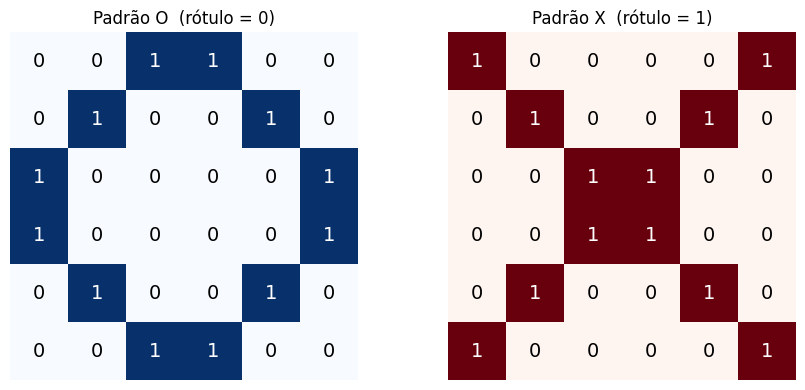

Dimensão de cada entrada: (6, 6)  (36 pixels)


In [2]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# Padrões base 6×6
O_base = np.array([
    [0, 0, 1, 1, 0, 0],
    [0, 1, 0, 0, 1, 0],
    [1, 0, 0, 0, 0, 1],
    [1, 0, 0, 0, 0, 1],
    [0, 1, 0, 0, 1, 0],
    [0, 0, 1, 1, 0, 0]
], dtype=float)

X_base = np.array([
    [1, 0, 0, 0, 0, 1],
    [0, 1, 0, 0, 1, 0],
    [0, 0, 1, 1, 0, 0],
    [0, 0, 1, 1, 0, 0],
    [0, 1, 0, 0, 1, 0],
    [1, 0, 0, 0, 0, 1]
], dtype=float)

# Visualização
fig, axes = plt.subplots(1, 2, figsize=(9, 4))
for ax, M, titulo, cmap in [
    (axes[0], O_base, 'Padrão O  (rótulo = 0)', 'Blues'),
    (axes[1], X_base, 'Padrão X  (rótulo = 1)', 'Reds'),
]:
    ax.imshow(M, cmap=cmap, vmin=0, vmax=1)
    for i in range(6):
        for j in range(6):
            ax.text(j, i, int(M[i, j]), ha='center', va='center',
                    fontsize=14, color='white' if M[i, j] > 0.5 else 'black')
    ax.set_title(titulo, fontsize=12)
    ax.axis('off')
plt.tight_layout()
plt.show()

print(f'Dimensão de cada entrada: {O_base.shape}  ({O_base.size} pixels)')


## 2. Limitação da FNN para Dados 2D

Uma rede totalmente conectada (FNN) precisaria achatar a matriz 6×6 em um vetor de **36 elementos**:

```
Entrada 6×6  →  Flatten  →  vetor 36×1  →  Dense  →  saída
```

| Problema | Implicação |
|----------|----------------------------|
| Muitos parâmetros | Uma imagem 100×100 exige 10 000 pesos por neurônio |
| Ignora estrutura espacial | Pixels vizinhos tratados como features independentes |
| Sem invariância de posição | O mesmo padrão deslocado gera entrada completamente diferente |

A **CNN** usa um filtro compartilhado que percorre toda a imagem, detectando o mesmo padrão em qualquer posição com muito menos parâmetros.


## 3. Como Funciona a CNN

### De onde vem o nome "Convolucional"?

O nome vem da operação matemática de **convolução**, clássica em processamento de sinais. A ideia central é: **deslizar uma função pequena sobre outra maior** e calcular o produto em cada posição.

Em imagens 2D, isso vira: deslizar um filtro (pequena matriz de pesos) sobre a imagem pixel a pixel, produzindo um mapa de respostas chamado *feature map*.

> **Detalhe técnico:** redes neurais usam na prática uma *correlação cruzada* (sem inverter o filtro), mas o nome "convolucional" ficou consagrado pelo uso histórico.

---

### O Filtro (Kernel)

O filtro é uma pequena matriz de pesos, geralmente **3×3**:

$$W_{\text{filtro}} \in \mathbb{R}^{3 \times 3}$$

Cada posição do filtro é um número que determina **o que ele detecta**: bordas verticais, horizontais, diagonais, texturas, etc.

**O filtro é treinável?**

**Sim.** Os pesos do filtro são parâmetros da rede, exatamente como os pesos de uma camada densa. Eles começam com valores aleatórios e são **ajustados pelo backpropagation** a cada iteração. A rede aprende sozinha quais filtros são úteis:

- Para classificar dígitos: aprende a detectar bordas e curvas
- Para classificar objetos: aprende texturas, formas, contornos

**Como o backpropagation ajusta o filtro?**

Calculamos o gradiente da loss em relação a cada peso do filtro:

$$\frac{\partial \mathcal{L}}{\partial W_{\text{conv}}} = \sum_{i,j} \delta_{ij} \cdot X_{i:i+F,\; j:j+F}$$

onde $\delta_{ij}$ é o erro que chegou da camada seguinte. Depois, atualizamos com SGD:

$$W_{\text{conv}} \leftarrow W_{\text{conv}} - \eta \cdot \frac{\partial \mathcal{L}}{\partial W_{\text{conv}}}$$

Isso é exatamente o que a função `grad_conv2d` calcula no nosso código.

---

### Passo 1: Produto Escalar (deslizamento do filtro)

O filtro percorre a imagem. Em cada posição $(i, j)$:

$$z_{ij} = \sum_{p=0}^{F-1} \sum_{q=0}^{F-1} x_{i+p,\, j+q} \cdot w_{pq} + b$$

### Passo 2: Feature Map

O resultado de todos os produtos escalares forma o *feature map*. Para entrada 6×6, filtro 3×3, stride 1: saída **4×4**

$$W_{out} = W_{in} - F + 1 = 6 - 3 + 1 = 4$$

### Passo 3: ReLU

$$A = \max(0,\, Z)$$

### Passo 4: Max Pooling 2×2

Mantém o valor máximo de cada bloco 2×2. Saída **2×2** (4 valores após Flatten).

In [3]:
# Demo: convolução manual no padrão O

W_demo = np.array([[0, 0, 1],
                   [0, 1, 0],
                   [1, 0, 0]], dtype=float)
b_demo = -2.0

# Janela top-left
janela = O_base[:3, :3]
z = np.sum(janela * W_demo) + b_demo
print('Filtro 3×3:')
print(W_demo)
print(f'\nJanela top-left do padrão O:\n{janela.astype(int)}')
print(f'\nDot product + bias = {np.sum(janela * W_demo):.0f} + ({b_demo}) = {z:.0f}')
print(f'→ z[0,0] do Feature Map = {z:.0f}')

# Feature map completo
Z = np.zeros((4, 4))
for i in range(4):
    for j in range(4):
        Z[i, j] = np.sum(O_base[i:i+3, j:j+3] * W_demo) + b_demo

print('\nFeature Map 4×4 (com bias):')
print(Z.astype(int))


Filtro 3×3:
[[0. 0. 1.]
 [0. 1. 0.]
 [1. 0. 0.]]

Janela top-left do padrão O:
[[0 0 1]
 [0 1 0]
 [1 0 0]]

Dot product + bias = 3 + (-2.0) = 1
→ z[0,0] do Feature Map = 1

Feature Map 4×4 (com bias):
[[ 1 -1 -2 -1]
 [-1 -2 -1 -2]
 [-2 -1 -2 -1]
 [-1 -2 -1  1]]


## 4. Arquitetura CNN para o Problema

| Camada | Entrada | Saída | Parâmetros |
|--------|---------|-------|------------|
| Conv 3×3 | (6, 6) | (4, 4) | 9 pesos + 1 bias |
| ReLU | (4, 4) | (4, 4) | |
| MaxPool 2×2 | (4, 4) | (2, 2) | |
| Flatten | (2, 2) | (4,) | |
| Dense | (4,) | (2,) | 8 pesos + 2 bias |
| **Total** | | | **20 parâmetros** |

> Compare com FNN: `Flatten(36) → Dense(36→2)` = **74 parâmetros**.


In [4]:
def conv2d(X, W, b):
    kH, kW = W.shape
    H_out = X.shape[0] - kH + 1
    W_out = X.shape[1] - kW + 1
    Z = np.zeros((H_out, W_out))
    for i in range(H_out):
        for j in range(W_out):
            Z[i, j] = np.sum(X[i:i+kH, j:j+kW] * W) + b
    return Z

def relu(Z):
    return np.maximum(0, Z)

def maxpool(A, pool=2):
    H_out = A.shape[0] // pool
    W_out = A.shape[1] // pool
    M = np.zeros((H_out, W_out))
    for i in range(H_out):
        for j in range(W_out):
            M[i, j] = np.max(A[i*pool:(i+1)*pool, j*pool:(j+1)*pool])
    return M

def softmax(z):
    e = np.exp(z - np.max(z))
    return e / e.sum()

print('conv2d, relu, maxpool, softmax definidos')

conv2d, relu, maxpool, softmax definidos


In [5]:
def grad_conv2d(dZ, X, W):
    kH, kW = W.shape
    dW = np.zeros_like(W)
    db = float(np.sum(dZ))
    for i in range(dZ.shape[0]):
        for j in range(dZ.shape[1]):
            dW += dZ[i, j] * X[i:i+kH, j:j+kW]
    return dW, db

def grad_relu(dA, Z):
    return dA * (Z > 0)

def grad_maxpool(dM, A, pool=2):
    dA = np.zeros_like(A)
    for i in range(dM.shape[0]):
        for j in range(dM.shape[1]):
            bloco = A[i*pool:(i+1)*pool, j*pool:(j+1)*pool]
            idx = np.unravel_index(np.argmax(bloco), bloco.shape)
            dA[i*pool + idx[0], j*pool + idx[1]] = dM[i, j]
    return dA

print('Funções de gradiente definidas.')

Funções de gradiente definidas.


## 5. Forward Pass Completo

O forward pass encadeia todos os blocos e retorna:
1. As **probabilidades** $[P(O),\; P(X)]$ via softmax
2. Um **cache** com valores intermediários usados no backward


Padrão O: P(O)=0.310  P(X)=0.690
Padrão X: P(O)=0.550  P(X)=0.450


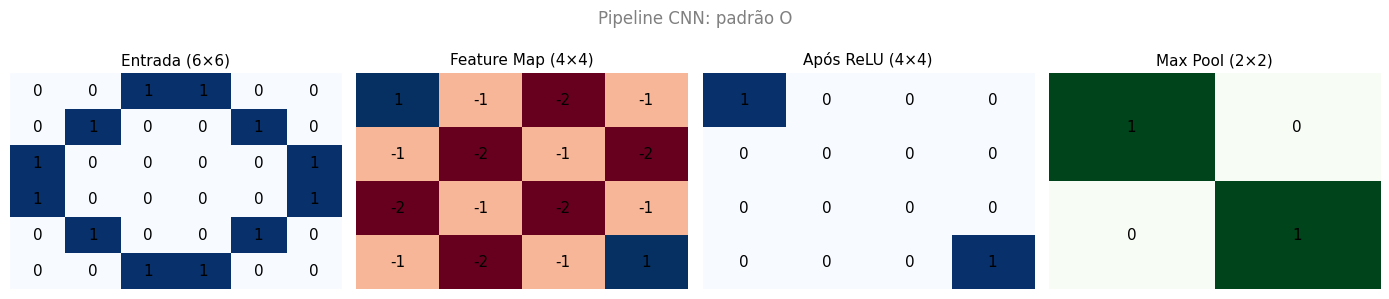

In [6]:
def forward(X, W_conv, b_conv, W_dense, b_dense):
    Z_conv = conv2d(X, W_conv, b_conv)          # (4, 4)
    A_conv = relu(Z_conv)                        # (4, 4)
    M      = maxpool(A_conv)                     # (2, 2)
    flat   = M.flatten()                         # (4,)
    probs  = softmax(W_dense @ flat + b_dense)   # (2,)
    cache  = (X, Z_conv, A_conv, M, flat)
    return probs, cache


# Teste com pesos iniciais
W_conv0  = np.array([[0, 0, 1], [0, 1, 0], [1, 0, 0]], dtype=float)
b_conv0  = -2.0
W_dense0 = np.array([[-0.80, -0.07, -0.20, -0.17],
                     [ 0.30,  0.50, -0.10,  0.40]], dtype=float)
b_dense0 = np.array([0.97, 0.10])

probs_O, _ = forward(O_base, W_conv0, b_conv0, W_dense0, b_dense0)
probs_X, _ = forward(X_base, W_conv0, b_conv0, W_dense0, b_dense0)

print(f'Padrão O: P(O)={probs_O[0]:.3f}  P(X)={probs_O[1]:.3f}')
print(f'Padrão X: P(O)={probs_X[0]:.3f}  P(X)={probs_X[1]:.3f}')

# Pipeline visual
_, (_, Z_o, A_o, M_o, _) = forward(O_base, W_conv0, b_conv0, W_dense0, b_dense0)

fig, axes = plt.subplots(1, 4, figsize=(14, 3))
for ax, mat, titulo, cmap in [
    (axes[0], O_base, 'Entrada (6×6)',    'Blues'),
    (axes[1], Z_o,    'Feature Map (4×4)', 'RdBu'),
    (axes[2], A_o,    'Após ReLU (4×4)',  'Blues'),
    (axes[3], M_o,    'Max Pool (2×2)',   'Greens'),
]:
    ax.imshow(mat, cmap=cmap, aspect='auto')
    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            ax.text(j, i, f'{mat[i,j]:.0f}', ha='center', va='center', fontsize=11)
    ax.set_title(titulo, fontsize=11)
    ax.axis('off')
plt.suptitle('Pipeline CNN: padrão O', fontsize=12, color='gray')
plt.tight_layout()
plt.show()

## 6. Backpropagation na CNN

O gradiente flui de trás para frente aplicando a **regra da cadeia**.

### Softmax + Cross-Entropy

$$\frac{\partial \mathcal{L}}{\partial \mathbf{z}_{\text{dense}}} = \mathbf{p} - \mathbf{y}$$

onde $\mathbf{p}$ são as probabilidades softmax e $\mathbf{y}$ é o rótulo one-hot.

### Camada Densa

$$\frac{\partial \mathcal{L}}{\partial W} = \mathbf{dz} \otimes \mathbf{x}^T \qquad
\frac{\partial \mathcal{L}}{\partial \mathbf{x}} = W^T \mathbf{dz}$$

### ReLU

$$\frac{\partial \mathcal{L}}{\partial Z} = \frac{\partial \mathcal{L}}{\partial A} \odot \mathbb{1}[Z > 0]$$

### Max Pooling

O gradiente vai apenas para a posição do máximo de cada janela.

### Convolução

$$\frac{\partial \mathcal{L}}{\partial W_{\text{conv}}} = \sum_{i,j} \frac{\partial \mathcal{L}}{\partial Z_{ij}} \cdot X_{i:i+F,\; j:j+F}$$


In [7]:
def backward(probs, y_label, cache, W_conv, W_dense):
    X, Z_conv, A_conv, M, flat = cache

    y    = np.zeros(2); y[y_label] = 1.0
    dz_d = probs - y                                        # gradiente saída

    dW_dense = np.outer(dz_d, flat)                         # gradiente Dense
    db_dense = dz_d.copy()
    d_flat   = W_dense.T @ dz_d

    dA_conv  = grad_maxpool(d_flat.reshape(M.shape), A_conv)  # gradiente MaxPool
    dZ_conv  = grad_relu(dA_conv, Z_conv)                     # gradiente ReLU
    dW_conv, db_conv = grad_conv2d(dZ_conv, X, W_conv)        # gradiente Conv

    return dW_conv, db_conv, dW_dense, db_dense


def cross_entropy(probs, y_label):
    return -np.log(probs[y_label] + 1e-9)


def predict(X, W_conv, b_conv, W_dense, b_dense):
    probs, _ = forward(X, W_conv, b_conv, W_dense, b_dense)
    return np.argmax(probs)


print('backward, cross_entropy e predict definidos.')

backward, cross_entropy e predict definidos.


## 7. Treinamento com Backpropagation

O loop de treinamento segue o ciclo padrão:

```
Para cada época:
    Para cada exemplo (Xᵢ, yᵢ):
        1. Forward  → probabilidades
        2. Loss     → cross-entropy
        3. Backward → gradientes
        4. Update   → W ← W − η · ∇W   (SGD)
```


Treino: 4000 amostras | Teste: 2000 amostras


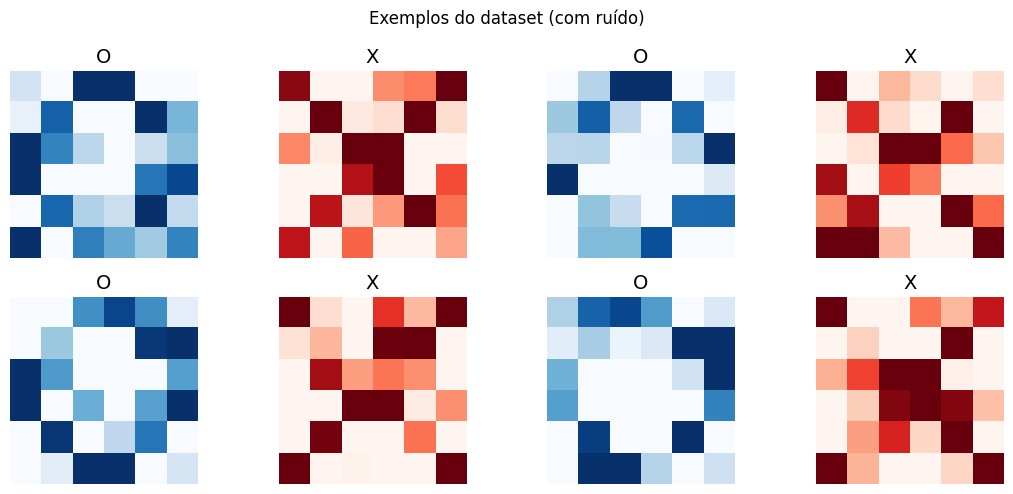

In [8]:
# Geração de dados com ruído gaussiano
def gerar_dataset(n=100, ruido=0.6, seed=42):
    rng = np.random.default_rng(seed)
    X_data, y_data = [], []
    for _ in range(n):
        X_data.append(np.clip(O_base + rng.normal(0, ruido, O_base.shape), 0, 1))
        y_data.append(0)
        X_data.append(np.clip(X_base + rng.normal(0, ruido, X_base.shape), 0, 1))
        y_data.append(1)
    return np.array(X_data), np.array(y_data)


X_train, y_train = gerar_dataset(n=2000, seed=42)
X_test,  y_test  = gerar_dataset(n=1000, seed=99)

print(f'Treino: {X_train.shape[0]} amostras | Teste: {X_test.shape[0]} amostras')

# Visualizar alguns exemplos
fig, axes = plt.subplots(2, 4, figsize=(11, 5))
for k, ax in enumerate(axes.flat):
    ax.imshow(X_train[k], cmap='Blues' if y_train[k] == 0 else 'Reds', vmin=0, vmax=1)
    ax.set_title('O' if y_train[k] == 0 else 'X', fontsize=14)
    ax.axis('off')
plt.suptitle('Exemplos do dataset (com ruído)', fontsize=12)
plt.tight_layout()
plt.show()


In [9]:
# Inicialização dos pesos
rng = np.random.default_rng(0)
W_conv  = rng.normal(0, 0.1, (3, 3))
b_conv  = 0.0
W_dense = rng.normal(0, 0.1, (2, 4))
b_dense = np.zeros(2)

# Loop de treinamento (SGD)
lr     = 0.05
epochs = 30
historico = []

for ep in range(epochs):
    perda_total = 0.0
    for i in np.random.permutation(len(X_train)):
        probs, cache = forward(X_train[i], W_conv, b_conv, W_dense, b_dense)
        perda_total += cross_entropy(probs, y_train[i])

        dW_conv, db_conv, dW_dense, db_dense = backward(probs, y_train[i], cache, W_conv, W_dense)

        W_conv  -= lr * dW_conv
        b_conv  -= lr * db_conv
        W_dense -= lr * dW_dense
        b_dense -= lr * db_dense

    historico.append(perda_total / len(X_train))
    if (ep + 1) % 10 == 0:
        print(f'Época {ep+1:3d}/{epochs}  |  Loss: {historico[-1]:.4f}')

print('\nTreinamento concluído.')

Época  10/30  |  Loss: 0.0584
Época  20/30  |  Loss: 0.0579
Época  30/30  |  Loss: 0.0561

Treinamento concluído.


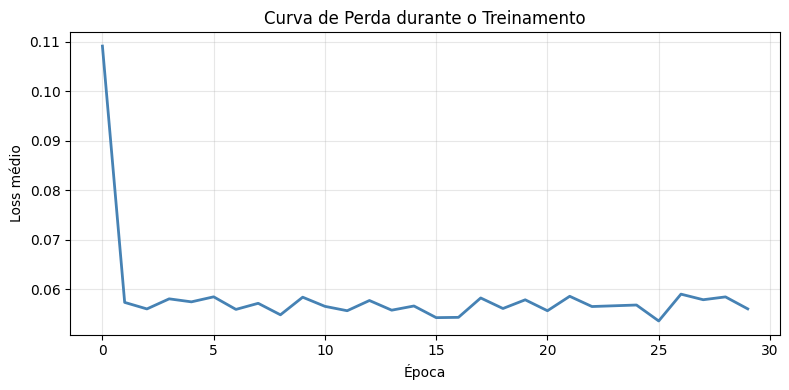

Acurácia no conjunto de teste: 98.5%


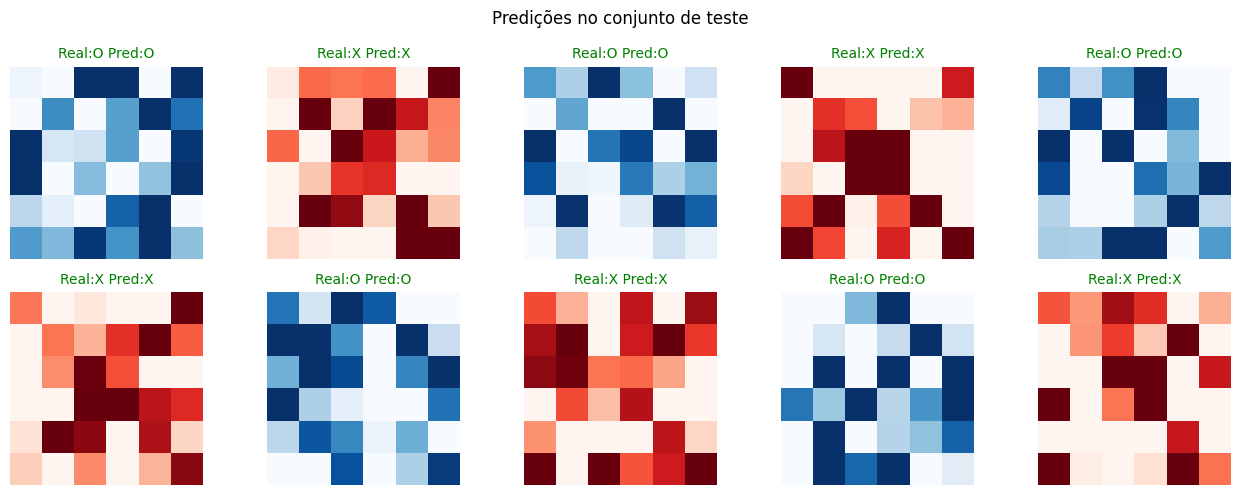

In [10]:
# Curva de perda
plt.figure(figsize=(8, 4))
plt.plot(historico, color='steelblue', linewidth=2)
plt.title('Curva de Perda durante o Treinamento')
plt.xlabel('Época'); plt.ylabel('Loss médio')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Acurácia no teste
preds    = np.array([predict(X_test[i], W_conv, b_conv, W_dense, b_dense) for i in range(len(X_test))])
acuracia = (preds == y_test).mean() * 100
print(f'Acurácia no conjunto de teste: {acuracia:.1f}%')

# Visualizar predições
fig, axes = plt.subplots(2, 5, figsize=(13, 5))
for k, ax in enumerate(axes.flat):
    real = 'O' if y_test[k] == 0 else 'X'
    pred = 'O' if preds[k] == 0 else 'X'
    ax.imshow(X_test[k], cmap='Blues' if y_test[k] == 0 else 'Reds', vmin=0, vmax=1)
    ax.set_title(f'Real:{real} Pred:{pred}', color='green' if real == pred else 'red', fontsize=10)
    ax.axis('off')
plt.suptitle('Predições no conjunto de teste', fontsize=12)
plt.tight_layout()
plt.show()


## 8. Conclusão

### O que aprendemos nesta aula

| Componente | O que faz | Equação principal |
|------------|-----------|-------------------|
| **Convolução** | Filtro deslizante detecta padrões locais | $z_{ij} = \sum_{p,q} x_{i+p,j+q} w_{pq} + b$ |
| **ReLU** | Introduz não-linearidade | $A = \max(0, Z)$ |
| **Max Pooling** | Reduz dimensionalidade | $M_{ij} = \max(\text{janela})$ |
| **Dense** | Combina features para classificação | $\mathbf{z} = W\mathbf{x} + b$ |
| **Backprop** | Ajusta pesos pelo gradiente | $\nabla W = \frac{\partial \mathcal{L}}{\partial W}$ |

### Por que a CNN é eficiente?

- **Compartilhamento de pesos:** o mesmo filtro detecta o padrão em qualquer posição
- **Localidade:** cada neurônio convolucional enxerga apenas uma janela pequena
- **Hierarquia:** camadas sucessivas compõem padrões simples em representações mais abstratas
